<a href="https://colab.research.google.com/github/scudilio/MBA---Deep-Learning/blob/main/Aula4_YOLO_Deteccao_Objetos_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 YOLO — Detecção de Objetos em Tempo Real

## FIAP — MBA em Data Science

---

### O que vamos fazer nesta aula

Vamos usar o **YOLOv8** (estado da arte em detecção de objetos) para:

1. Detectar objetos em imagens estáticas
2. Entender o que o modelo retorna (bounding boxes, classes, confiança)
3. Contar objetos por classe
4. Comparar diferentes tamanhos de modelo (nano vs medium)
5. Detecção em tempo real pela webcam

O modelo YOLOv8 vem **pré-treinado no dataset COCO** com **80 classes** (pessoa, carro, cachorro, gato, celular, etc.).

---

## 📚 Revisão Rápida: Como o YOLO funciona

### O nome diz tudo: You Only Look Once

O YOLO processa a imagem **uma única vez** pela rede neural e já retorna todas as detecções. Isso o torna extremamente rápido.

### Pipeline simplificado

```
Imagem → CNN (extrai features) → Grid S×S → Cada célula prevê:
                                                 📦 Bounding Box (x, y, w, h)
                                                 🎯 Confiança (tem objeto?)
                                                 🏷️ Classe (pessoa, carro...)
                                             → NMS (remove duplicatas) → Detecções finais
```

### Modelos disponíveis no YOLOv8

| Modelo | Parâmetros | Velocidade | Precisão (mAP) | Uso ideal |
|--------|-----------|------------|----------------|----------|
| YOLOv8n (nano) | 3.2M | Muito rápido | 37.3 | Mobile, IoT, tempo real |
| YOLOv8s (small) | 11.2M | Rápido | 44.9 | Equilíbrio |
| YOLOv8m (medium) | 25.9M | Médio | 50.2 | Boa precisão |
| YOLOv8l (large) | 43.7M | Lento | 52.9 | Alta precisão |
| YOLOv8x (extra) | 68.2M | Muito lento | 53.9 | Máxima precisão |

---

## 1️⃣ Instalação e Setup

In [2]:
# ============================================================
# INSTALAÇÃO — execute apenas uma vez
# ============================================================
# ultralytics: biblioteca oficial do YOLOv8 (inclui tudo que precisamos)
# opencv-python: processamento de imagens e vídeo

!pip install ultralytics opencv-python -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.6 MB/s eta 0:00:00


In [3]:
# ============================================================
# IMPORTS
# ============================================================

from ultralytics import YOLO      # Modelo YOLO (detecção de objetos)
import cv2                         # OpenCV (processamento de imagem/vídeo)
import matplotlib.pyplot as plt    # Visualização de gráficos
import numpy as np                 # Operações numéricas
from collections import Counter    # Contagem de objetos por classe
import time                        # Medir tempo de inferência

print("Tudo importado com sucesso!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Tudo importado com sucesso!


---

## 2️⃣ Carregando o Modelo Pré-Treinado

O YOLOv8 vem pré-treinado no **dataset COCO** (Common Objects in Context) com **80 classes** do dia-a-dia.

Na primeira execução, o modelo é baixado automaticamente (~6MB para o nano).

In [4]:
# ============================================================
# CARREGANDO O MODELO YOLOv8 NANO
# ============================================================
# 'yolov8n.pt' = versão nano (mais leve e rápida)
# Na primeira execução, o arquivo .pt é baixado automaticamente
# O modelo já sabe detectar 80 tipos de objetos!

modelo = YOLO("yolov8n.pt")

print(f"Modelo carregado: YOLOv8 Nano")
print(f"Número de classes: {len(modelo.names)}")
print(f"\nTodas as 80 classes que o modelo reconhece:")
print("-" * 60)

# Mostrando todas as classes organizadas
for i, nome in modelo.names.items():
    print(f"  {i:2d}: {nome}", end="")
    if (i + 1) % 5 == 0:
        print()  # Quebra de linha a cada 5 classes

Modelo carregado: YOLOv8 Nano
Número de classes: 80

Todas as 80 classes que o modelo reconhece:
------------------------------------------------------------
   0: person   1: bicycle   2: car   3: motorcycle   4: airplane
   5: bus   6: train   7: truck   8: boat   9: traffic light
  10: fire hydrant  11: stop sign  12: parking meter  13: bench  14: bird
  15: cat  16: dog  17: horse  18: sheep  19: cow
  20: elephant  21: bear  22: zebra  23: giraffe  24: backpack
  25: umbrella  26: handbag  27: tie  28: suitcase  29: frisbee
  30: skis  31: snowboard  32: sports ball  33: kite  34: baseball bat
  35: baseball glove  36: skateboard  37: surfboard  38: tennis racket  39: bottle
  40: wine glass  41: cup  42: fork  43: knife  44: spoon
  45: bowl  46: banana  47: apple  48: sandwich  49: orange
  50: broccoli  51: carrot  52: hot dog  53: pizza  54: donut
  55: cake  56: chair  57: couch  58: potted plant  59: bed
  60: dining table  61: toilet  62: tv  63: laptop  64: mouse
  65: rem

---

## 3️⃣ Detecção em Imagem Estática

### O que acontece quando chamamos `modelo(imagem)`?

1. A imagem é redimensionada para 640×640
2. Passa pela CNN do YOLO (backbone → neck → head)
3. O modelo prevê bounding boxes + classes + confiança
4. Non-Max Suppression remove caixas duplicadas
5. Retorna uma lista de `Results` com todas as detecções

### Vamos usar uma imagem de exemplo

Coloque qualquer imagem `.jpg` no mesmo diretório, ou use uma URL.

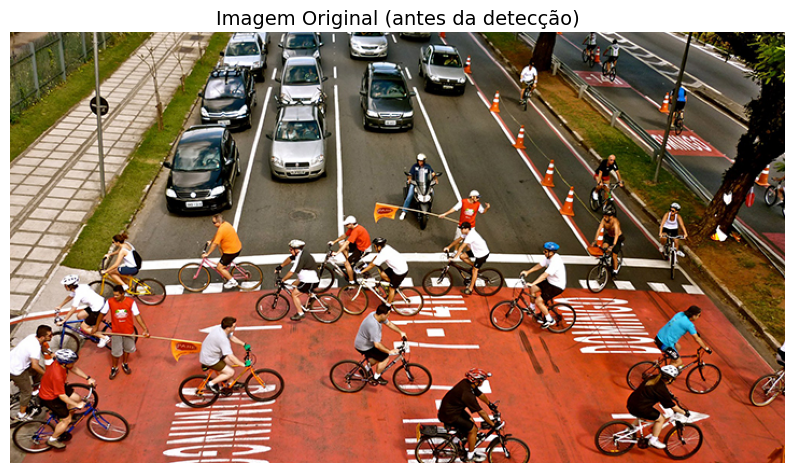

Tamanho da imagem: 720×400 pixels
Canais: 3 (BGR)


In [13]:
# ============================================================
# DETECÇÃO EM IMAGEM LOCAL
# ============================================================
# Substitua 'imagem.jpg' pelo caminho da sua imagem
# Pode ser qualquer foto: rua, escritório, parque, etc.

caminho_imagem = "1-ciclofaixa.jpg"#"cat.jpg"  # <-- ALTERE AQUI

# Carrega a imagem com OpenCV
img_original = cv2.imread(caminho_imagem)

# OpenCV carrega em BGR, matplotlib espera RGB — precisamos converter
img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

# Mostra a imagem original
plt.figure(figsize=(10, 7))
plt.imshow(img_rgb)
plt.title("Imagem Original (antes da detecção)", fontsize=14)
plt.axis("off")
plt.show()

print(f"Tamanho da imagem: {img_original.shape[1]}×{img_original.shape[0]} pixels")
print(f"Canais: {img_original.shape[2]} (BGR)")

In [14]:
# ============================================================
# EXECUTANDO A DETECÇÃO
# ============================================================
# Basta passar o caminho da imagem para o modelo!
# O YOLO faz TUDO sozinho: resize, normalização, inferência, NMS

inicio = time.time()  # Marca o tempo de início

resultados = modelo(caminho_imagem)  # <-- DETECÇÃO ACONTECE AQUI

tempo_inferencia = time.time() - inicio

print(f"\nTempo de inferência: {tempo_inferencia*1000:.1f} ms")
print(f"FPS equivalente: {1/tempo_inferencia:.1f} frames por segundo")


image 1/1 /content/1-ciclofaixa.jpg: 384x640 23 persons, 13 bicycles, 6 cars, 2 buss, 148.9ms
Speed: 3.2ms preprocess, 148.9ms inference, 4.9ms postprocess per image at shape (1, 3, 384, 640)

Tempo de inferência: 173.7 ms
FPS equivalente: 5.8 frames por segundo


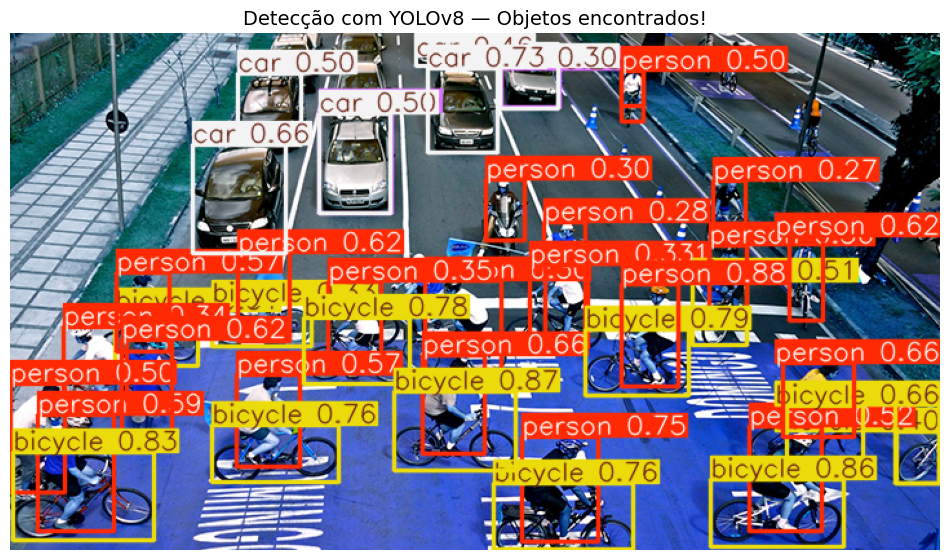

In [15]:
# ============================================================
# VISUALIZANDO O RESULTADO
# ============================================================
# O método .plot() desenha automaticamente:
# - Bounding boxes ao redor de cada objeto
# - Nome da classe
# - Confiança (%) da detecção

# .plot() retorna a imagem com as detecções desenhadas (em RGB)
imagem_detectada = resultados[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(imagem_detectada)
plt.title("Detecção com YOLOv8 — Objetos encontrados!", fontsize=14)
plt.axis("off")
plt.show()

---

## 4️⃣ Entendendo os Resultados — O que o YOLO retorna?

Cada detecção contém 3 informações:

| Informação | Descrição | Exemplo |
|-----------|-----------|--------|
| **Bounding Box** | Coordenadas (x1, y1, x2, y2) do retângulo | (120, 50, 380, 420) |
| **Classe** | Tipo do objeto detectado | "person", "car", "dog" |
| **Confiança** | Probabilidade da detecção estar correta | 0.92 (92%) |

As coordenadas (x1, y1) são o canto **superior esquerdo** e (x2, y2) o canto **inferior direito** do retângulo.

In [16]:
# ============================================================
# ANALISANDO CADA DETECÇÃO EM DETALHE
# ============================================================
# Vamos extrair e exibir cada objeto encontrado

# 'boxes' contém todas as detecções
deteccoes = resultados[0].boxes

print(f"Total de objetos detectados: {len(deteccoes)}")
print("=" * 60)

for i, box in enumerate(deteccoes):

    # Coordenadas da bounding box (x1, y1, x2, y2)
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

    # ID numérico da classe
    classe_id = int(box.cls[0])

    # Nome da classe (ex: 'person', 'car', 'dog')
    classe_nome = modelo.names[classe_id]

    # Confiança (0 a 1)
    confianca = float(box.conf[0])

    # Tamanho do objeto em pixels
    largura = x2 - x1
    altura = y2 - y1

    print(f"\n🔍 Detecção {i+1}:")
    print(f"   Objeto:    {classe_nome}")
    print(f"   Confiança: {confianca:.1%}")
    print(f"   Posição:   ({x1:.0f}, {y1:.0f}) → ({x2:.0f}, {y2:.0f})")
    print(f"   Tamanho:   {largura:.0f} × {altura:.0f} pixels")

Total de objetos detectados: 44

🔍 Detecção 1:
   Objeto:    person
   Confiança: 87.8%
   Posição:   (473, 194) → (517, 274)
   Tamanho:   44 × 79 pixels

🔍 Detecção 2:
   Objeto:    bicycle
   Confiança: 87.4%
   Posição:   (297, 278) → (391, 338)
   Tamanho:   94 × 60 pixels

🔍 Detecção 3:
   Objeto:    bicycle
   Confiança: 86.4%
   Posição:   (542, 345) → (645, 397)
   Tamanho:   103 × 52 pixels

🔍 Detecção 4:
   Objeto:    bicycle
   Confiança: 82.7%
   Posição:   (2, 325) → (111, 392)
   Tamanho:   109 × 67 pixels

🔍 Detecção 5:
   Objeto:    bicycle
   Confiança: 79.0%
   Posição:   (445, 229) → (526, 280)
   Tamanho:   80 × 51 pixels

🔍 Detecção 6:
   Objeto:    bicycle
   Confiança: 78.0%
   Posição:   (227, 221) → (309, 272)
   Tamanho:   82 × 51 pixels

🔍 Detecção 7:
   Objeto:    bicycle
   Confiança: 76.0%
   Posição:   (375, 349) → (483, 400)
   Tamanho:   108 × 51 pixels

🔍 Detecção 8:
   Objeto:    bicycle
   Confiança: 75.9%
   Posição:   (157, 304) → (254, 348)
   Ta

In [17]:
# ============================================================
# CONTAGEM DE OBJETOS POR CLASSE
# ============================================================
# Quantos objetos de cada tipo foram detectados?

# Extrai o nome de cada classe detectada
classes_detectadas = [modelo.names[int(box.cls[0])] for box in deteccoes]

# Conta quantos de cada
contagem = Counter(classes_detectadas)

print("📊 Contagem de objetos por classe:")
print("=" * 40)
for classe, qtd in contagem.most_common():
    barra = "█" * (qtd * 3)  # Barra visual proporcional
    print(f"   {classe:15s} {qtd:3d}  {barra}")

print(f"\n   {'TOTAL':15s} {len(deteccoes):3d}")

📊 Contagem de objetos por classe:
   person           23  █████████████████████████████████████████████████████████████████████
   bicycle          13  ███████████████████████████████████████
   car               6  ██████████████████
   bus               2  ██████

   TOTAL            44


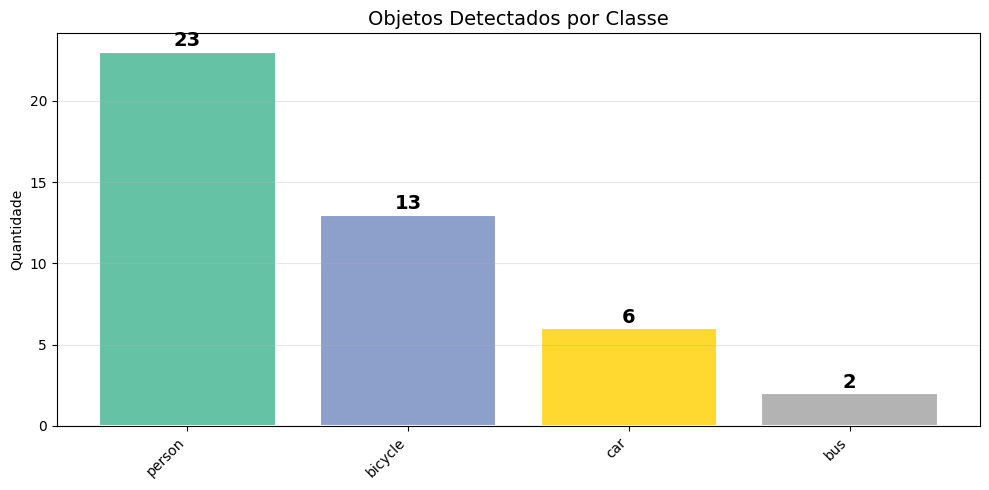

In [18]:
# ============================================================
# GRÁFICO DE BARRAS DA CONTAGEM
# ============================================================

if len(contagem) > 0:
    classes = list(contagem.keys())
    quantidades = list(contagem.values())

    # Cores para cada barra
    cores = plt.cm.Set2(np.linspace(0, 1, len(classes)))

    plt.figure(figsize=(10, 5))
    barras = plt.bar(classes, quantidades, color=cores, edgecolor='white', linewidth=1.5)

    # Adiciona o número acima de cada barra
    for barra, qtd in zip(barras, quantidades):
        plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.1,
                 str(qtd), ha='center', va='bottom', fontsize=14, fontweight='bold')

    plt.title("Objetos Detectados por Classe", fontsize=14)
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum objeto detectado na imagem.")

---

## 5️⃣ Recortando e Exibindo Cada Objeto Detectado

Vamos usar as coordenadas das bounding boxes para **recortar** cada objeto da imagem original. Isso mostra exatamente o que o YOLO encontrou.

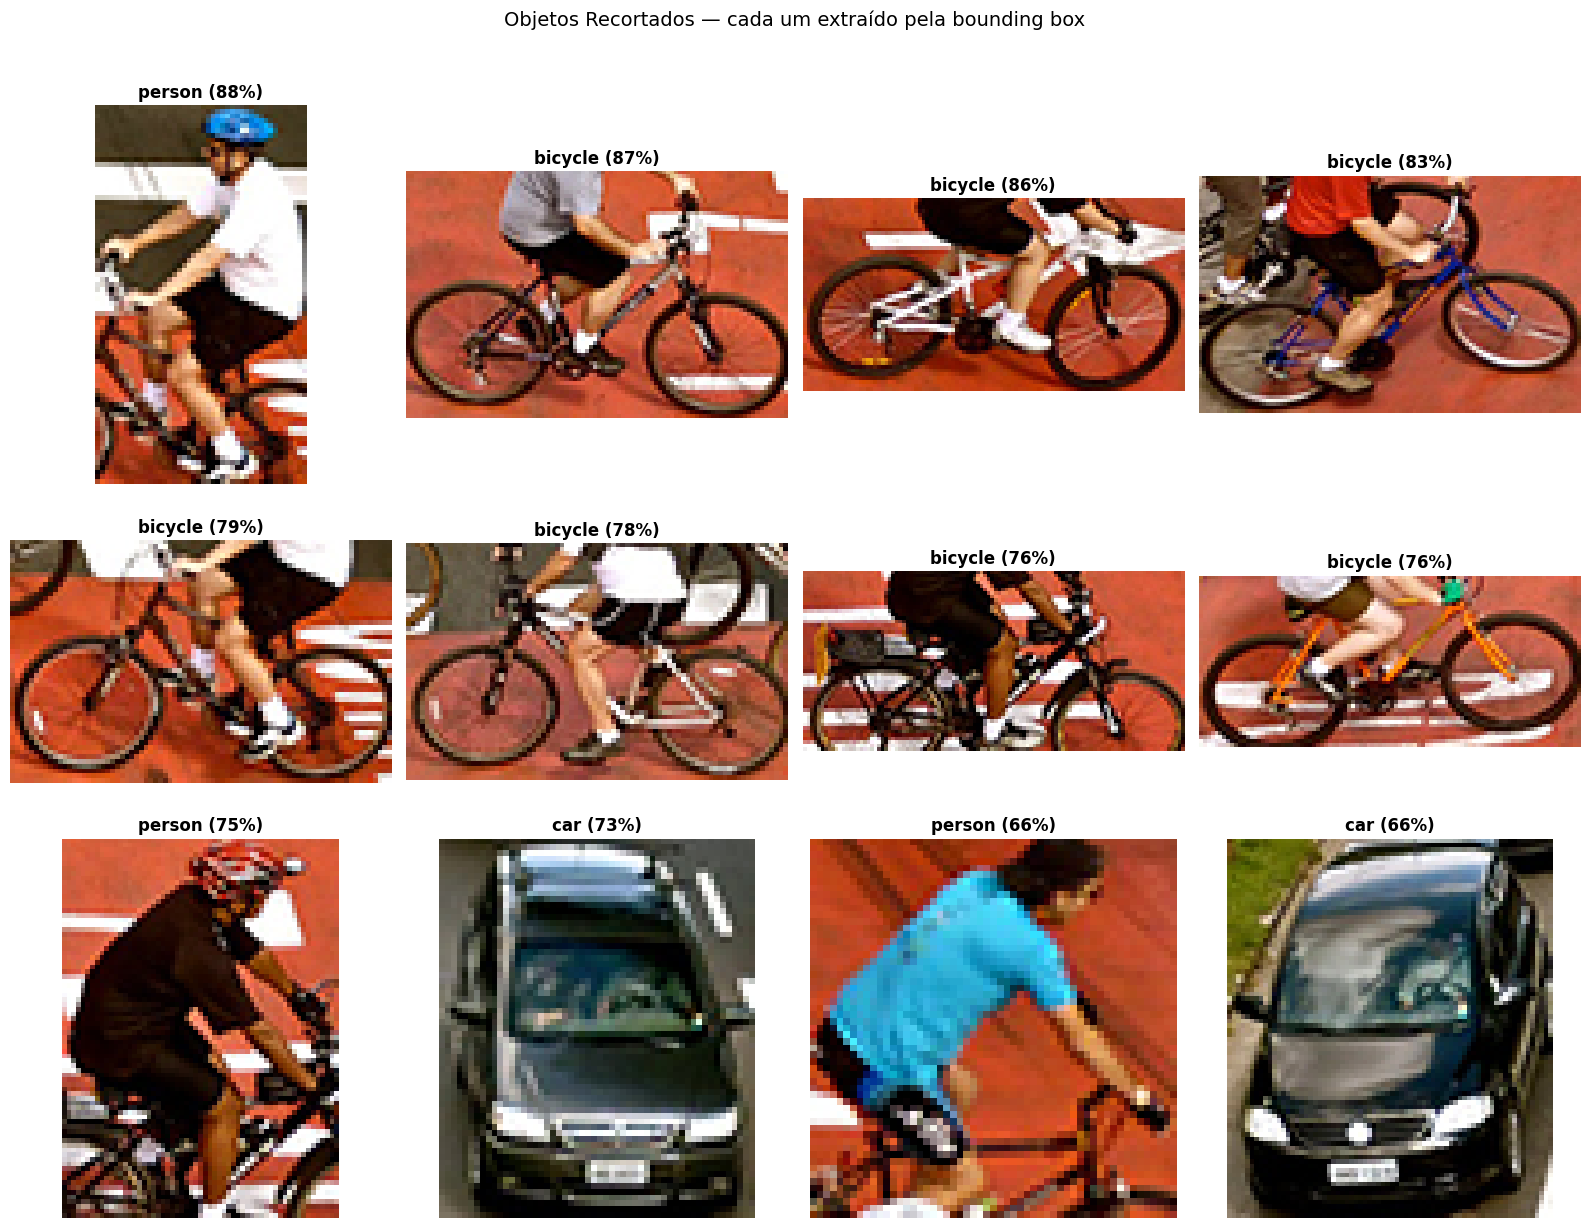

In [19]:
# ============================================================
# RECORTANDO CADA OBJETO DETECTADO
# ============================================================
# Usa as coordenadas da bounding box para extrair o objeto da imagem

n_objetos = min(len(deteccoes), 12)  # Máximo 12 para caber na tela

if n_objetos > 0:
    # Calcula grid de subplots
    cols = min(n_objetos, 4)
    rows = (n_objetos + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if n_objetos == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    for i in range(n_objetos):
        box = deteccoes[i]
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        classe_nome = modelo.names[int(box.cls[0])]
        confianca = float(box.conf[0])

        # Recorta o objeto da imagem RGB
        recorte = img_rgb[y1:y2, x1:x2]

        axes[i].imshow(recorte)
        axes[i].set_title(f"{classe_nome} ({confianca:.0%})", fontsize=12, fontweight='bold')
        axes[i].axis('off')

    # Esconde subplots vazios
    for j in range(n_objetos, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Objetos Recortados — cada um extraído pela bounding box", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum objeto detectado para recortar.")

---

## 6️⃣ Detecção com Filtro de Confiança

Às vezes o YOLO detecta objetos com baixa confiança ("ruído"). Podemos filtrar para mostrar apenas detecções com **confiança acima de um threshold**.


image 1/1 /content/1-ciclofaixa.jpg: 384x640 2 persons, 7 bicycles, 1 car, 129.3ms
Speed: 2.3ms preprocess, 129.3ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/1-ciclofaixa.jpg: 384x640 26 persons, 14 bicycles, 7 cars, 3 buss, 1 truck, 1 traffic light, 121.9ms
Speed: 2.1ms preprocess, 121.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


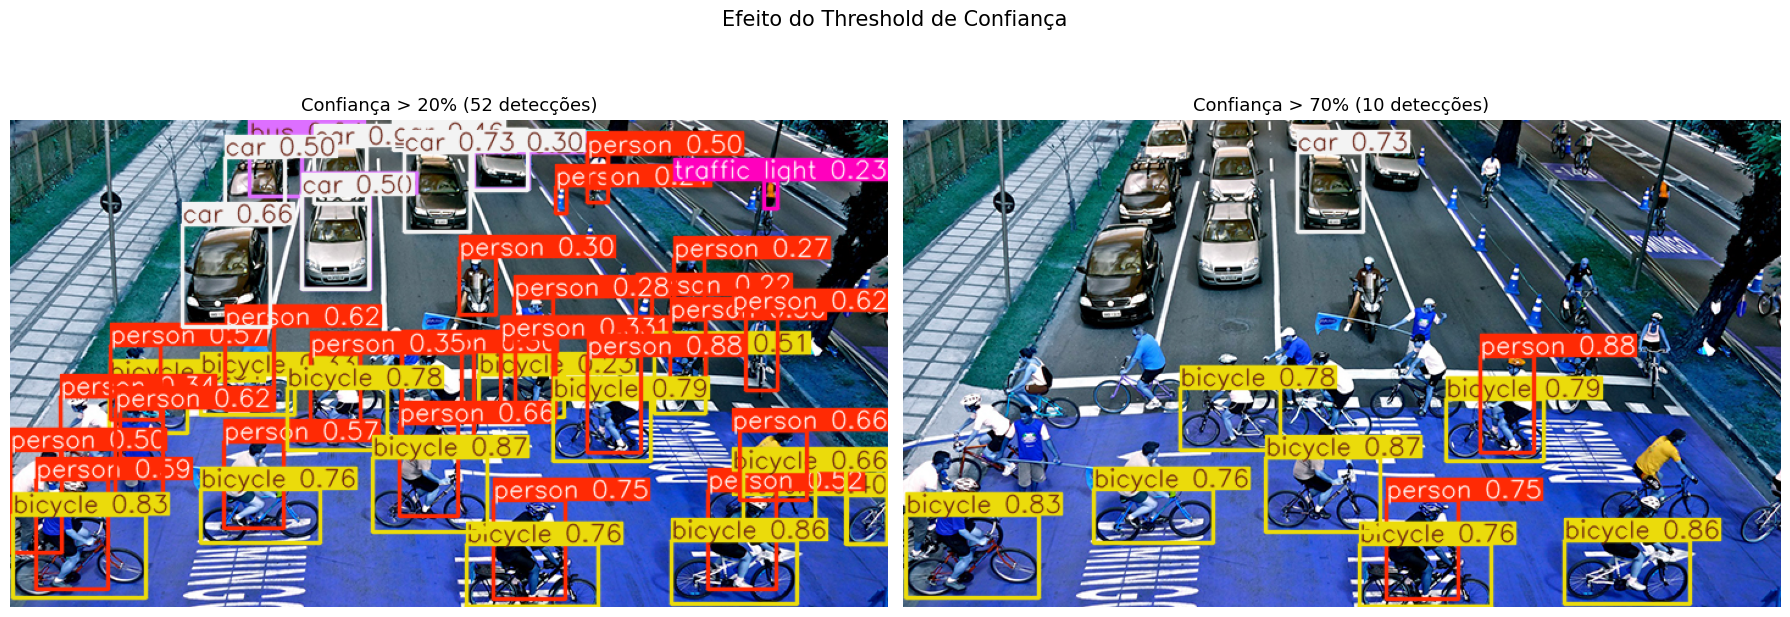

Threshold BAIXO: mais detecções, mas pode incluir falsos positivos
Threshold ALTO:  menos detecções, mas mais confiáveis


In [20]:
# ============================================================
# DETECÇÃO COM THRESHOLD DE CONFIANÇA PERSONALIZADO
# ============================================================
# O parâmetro 'conf' define o limiar mínimo de confiança
# Apenas detecções ACIMA desse valor são retornadas

# Rodando com threshold alto (apenas detecções muito confiantes)
resultados_alto = modelo(caminho_imagem, conf=0.7)  # Apenas confiança > 70%

# Rodando com threshold baixo (mais detecções, mas mais ruído)
resultados_baixo = modelo(caminho_imagem, conf=0.2)  # Confiança > 20%

# Comparação visual lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(resultados_baixo[0].plot())
axes[0].set_title(f"Confiança > 20% ({len(resultados_baixo[0].boxes)} detecções)", fontsize=13)
axes[0].axis("off")

axes[1].imshow(resultados_alto[0].plot())
axes[1].set_title(f"Confiança > 70% ({len(resultados_alto[0].boxes)} detecções)", fontsize=13)
axes[1].axis("off")

plt.suptitle("Efeito do Threshold de Confiança", fontsize=15)
plt.tight_layout()
plt.show()

print("Threshold BAIXO: mais detecções, mas pode incluir falsos positivos")
print("Threshold ALTO:  menos detecções, mas mais confiáveis")

---

## 7️⃣ Comparando Modelos: Nano vs Medium

Vamos comparar o modelo **nano** (rápido) com o **medium** (preciso) na mesma imagem.


image 1/1 /content/1-ciclofaixa.jpg: 384x640 23 persons, 13 bicycles, 6 cars, 2 buss, 133.3ms
Speed: 4.1ms preprocess, 133.3ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/1-ciclofaixa.jpg: 384x640 22 persons, 19 bicycles, 9 cars, 1 motorcycle, 1031.6ms
Speed: 2.2ms preprocess, 1031.6ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


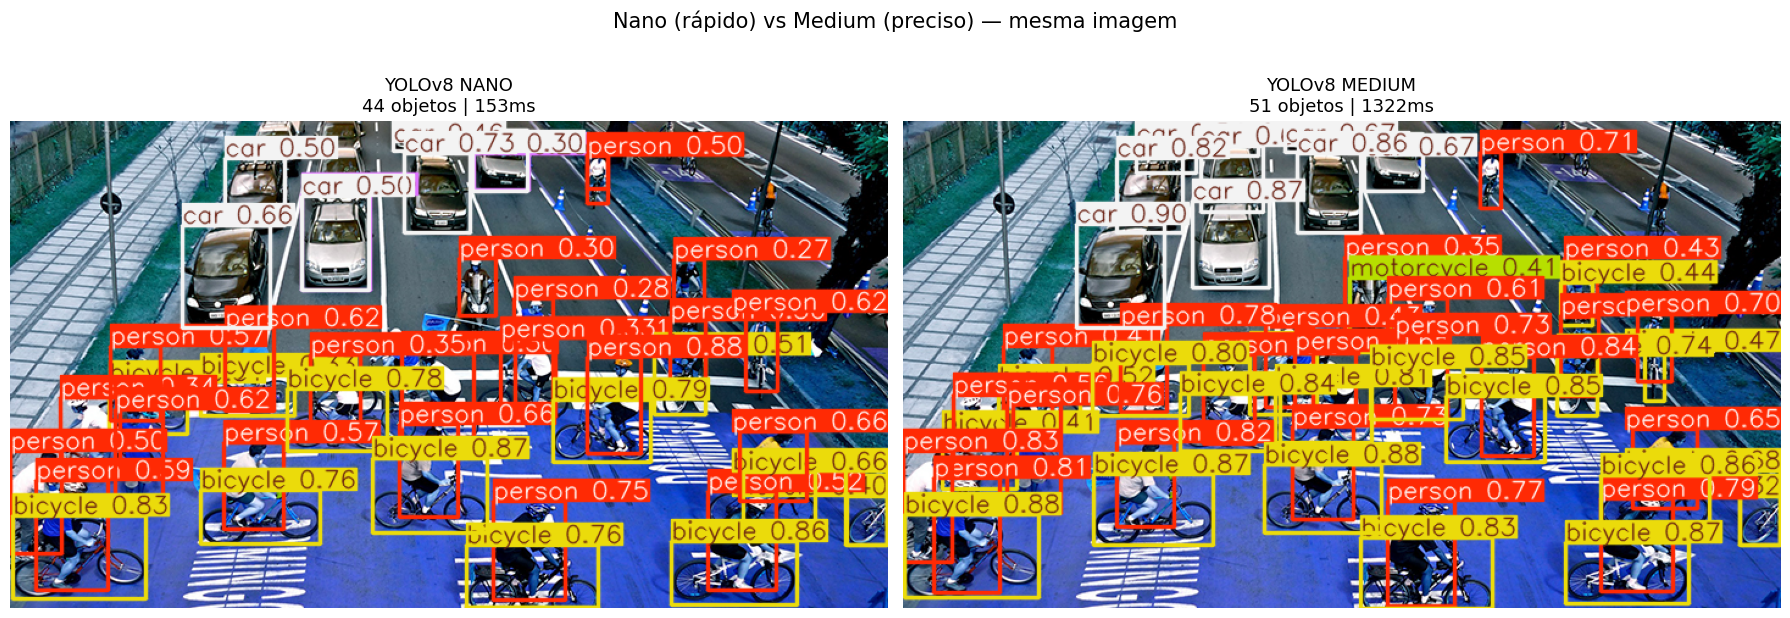


📊 Comparação:
   Nano:   44 objetos em 153ms (7 FPS)
   Medium: 51 objetos em 1322ms (1 FPS)

   O Medium é 8.7x mais lento, mas detecta mais objetos!


In [21]:
# ============================================================
# COMPARAÇÃO: NANO vs MEDIUM
# ============================================================
# O modelo medium tem mais parâmetros → mais preciso, porém mais lento

# Carrega o modelo medium (será baixado na primeira vez, ~50MB)
modelo_medium = YOLO("yolov8m.pt")

# Inferência com nano
inicio_nano = time.time()
res_nano = modelo(caminho_imagem)
tempo_nano = time.time() - inicio_nano

# Inferência com medium
inicio_medium = time.time()
res_medium = modelo_medium(caminho_imagem)
tempo_medium = time.time() - inicio_medium

# Visualização comparativa
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(res_nano[0].plot())
axes[0].set_title(f"YOLOv8 NANO\n{len(res_nano[0].boxes)} objetos | {tempo_nano*1000:.0f}ms", fontsize=13)
axes[0].axis("off")

axes[1].imshow(res_medium[0].plot())
axes[1].set_title(f"YOLOv8 MEDIUM\n{len(res_medium[0].boxes)} objetos | {tempo_medium*1000:.0f}ms", fontsize=13)
axes[1].axis("off")

plt.suptitle("Nano (rápido) vs Medium (preciso) — mesma imagem", fontsize=15)
plt.tight_layout()
plt.show()

print(f"\n📊 Comparação:")
print(f"   Nano:   {len(res_nano[0].boxes):2d} objetos em {tempo_nano*1000:.0f}ms ({1/tempo_nano:.0f} FPS)")
print(f"   Medium: {len(res_medium[0].boxes):2d} objetos em {tempo_medium*1000:.0f}ms ({1/tempo_medium:.0f} FPS)")
print(f"\n   O Medium é {tempo_medium/tempo_nano:.1f}x mais lento, mas detecta mais objetos!")

---

## 8️⃣ Detecção por URL — Sem precisar baixar imagem

O YOLOv8 aceita URLs diretamente! Vamos testar com imagens da internet.


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 158.3ms
Speed: 5.5ms preprocess, 158.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)


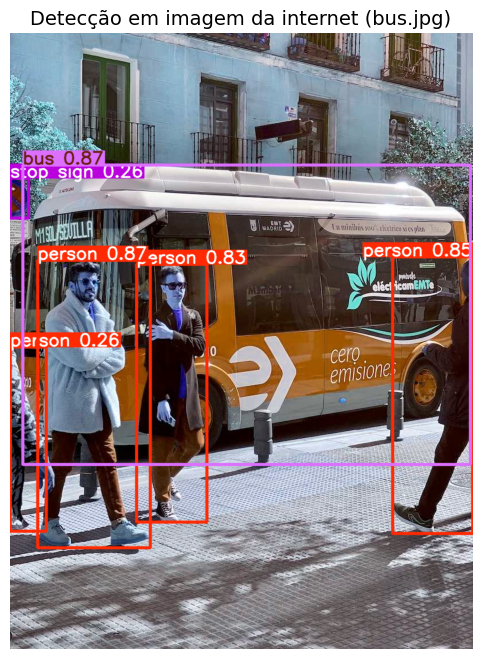

Objetos encontrados: {'bus': 1, 'person': 4, 'stop sign': 1}


In [22]:
# ============================================================
# DETECÇÃO EM IMAGEM DA INTERNET
# ============================================================
# O YOLO aceita URL como input — baixa e processa automaticamente
# Substitua pela URL de qualquer imagem

url = "https://ultralytics.com/images/bus.jpg"  # Imagem clássica de teste

resultados_url = modelo(url)

plt.figure(figsize=(12, 8))
plt.imshow(resultados_url[0].plot())
plt.title("Detecção em imagem da internet (bus.jpg)", fontsize=14)
plt.axis("off")
plt.show()

# Contagem
classes_url = [modelo.names[int(b.cls[0])] for b in resultados_url[0].boxes]
print(f"Objetos encontrados: {dict(Counter(classes_url))}")

---

## 9️⃣ Desenhando Bounding Boxes Manualmente (sem .plot())

Para entender melhor o que está por trás, vamos **desenhar as caixas manualmente** usando OpenCV. Isso mostra exatamente como as coordenadas funcionam.

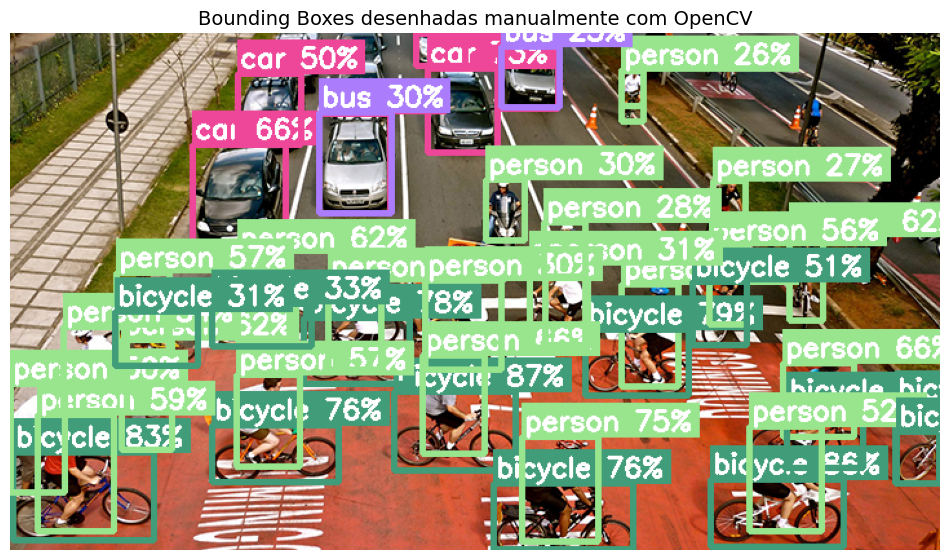

Cada retângulo foi desenhado usando cv2.rectangle(img, (x1,y1), (x2,y2), cor, espessura)
As coordenadas (x1,y1) e (x2,y2) vêm diretamente do YOLO!


In [23]:
# ============================================================
# DESENHO MANUAL DAS BOUNDING BOXES
# ============================================================
# Em vez de usar .plot(), vamos desenhar nós mesmos
# Isso mostra exatamente como as coordenadas são usadas

# Copia a imagem original para desenhar em cima
img_manual = img_rgb.copy()

# Cores para diferentes classes (BGR convertido para RGB)
np.random.seed(42)
cores_classes = {}

for box in resultados[0].boxes:
    # Extrai informações
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
    classe_id = int(box.cls[0])
    classe_nome = modelo.names[classe_id]
    confianca = float(box.conf[0])

    # Gera cor única por classe
    if classe_nome not in cores_classes:
        cores_classes[classe_nome] = tuple(np.random.randint(50, 255, 3).tolist())
    cor = cores_classes[classe_nome]

    # Desenha o retângulo (bounding box)
    cv2.rectangle(img_manual, (x1, y1), (x2, y2), cor, 3)

    # Prepara o texto: "classe 95%"
    texto = f"{classe_nome} {confianca:.0%}"

    # Fundo do texto (para legibilidade)
    (tw, th), _ = cv2.getTextSize(texto, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    cv2.rectangle(img_manual, (x1, y1 - th - 10), (x1 + tw + 5, y1), cor, -1)

    # Escreve o texto
    cv2.putText(img_manual, texto, (x1 + 2, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

plt.figure(figsize=(12, 8))
plt.imshow(img_manual)
plt.title("Bounding Boxes desenhadas manualmente com OpenCV", fontsize=14)
plt.axis("off")
plt.show()

print("Cada retângulo foi desenhado usando cv2.rectangle(img, (x1,y1), (x2,y2), cor, espessura)")
print("As coordenadas (x1,y1) e (x2,y2) vêm diretamente do YOLO!")

---

## 🔟 Detecção em Tempo Real — Webcam

### Como funciona

1. Abrimos a webcam com OpenCV (`cv2.VideoCapture`)
2. A cada frame capturado, passamos pelo YOLO
3. O YOLO retorna as detecções
4. Desenhamos as bounding boxes no frame
5. Exibimos na tela em tempo real
6. Pressione **ESC** para parar

### ⚠️ Importante

- Este código funciona **localmente** (não funciona no Google Colab com `cv2.imshow`)
- Para Colab, use a versão alternativa com `IPython.display` (célula seguinte)
- Com GPU, espere **30-60+ FPS**. Com CPU, **5-15 FPS**

In [24]:
# ============================================================
# DETECÇÃO EM TEMPO REAL — WEBCAM (versão local)
# ============================================================
# Funciona no Jupyter local, VS Code, scripts Python
# NÃO funciona no Google Colab (use a versão Colab abaixo)
#
# Pressione ESC para parar a detecção
# ============================================================

# Abre a webcam (0 = câmera padrão)
captura = cv2.VideoCapture(0)

# Verifica se a câmera abriu
if not captura.isOpened():
    print("ERRO: Não foi possível abrir a webcam!")
else:
    print("Webcam aberta! Pressione ESC para parar.")
    print("Apontando a câmera para objetos do dia-a-dia...")
    print("O YOLO detecta: pessoas, celulares, garrafas, laptops, mouses, teclados, etc.")

    while True:
        # Captura um frame da webcam
        ret, frame = captura.read()

        # Se não conseguiu capturar, sai do loop
        if not ret:
            print("Erro ao capturar frame")
            break

        # Mede o tempo de inferência
        t1 = time.time()

        # Passa o frame pelo YOLO
        resultados_cam = modelo(frame, verbose=False)  # verbose=False para não poluir o terminal

        t2 = time.time()
        fps = 1 / (t2 - t1)

        # Desenha as detecções no frame
        frame_detectado = resultados_cam[0].plot()

        # Adiciona o FPS no canto superior esquerdo
        cv2.putText(frame_detectado, f"FPS: {fps:.1f}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        # Adiciona contagem de objetos
        n_objetos = len(resultados_cam[0].boxes)
        cv2.putText(frame_detectado, f"Objetos: {n_objetos}", (10, 65),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        # Mostra o frame na tela
        cv2.imshow("YOLO Tempo Real — Pressione ESC para sair", frame_detectado)

        # ESC (tecla 27) para sair
        if cv2.waitKey(1) & 0xFF == 27:
            break

    # Libera a câmera e fecha a janela
    captura.release()
    cv2.destroyAllWindows()
    print("\nWebcam encerrada!")

ERRO: Não foi possível abrir a webcam!


### Versão para Google Colab

No Colab, `cv2.imshow` não funciona. Usamos `IPython.display` para mostrar os frames inline.

<IPython.core.display.Javascript object>


0: 480x640 1 person, 1 suitcase, 235.1ms
Speed: 4.7ms preprocess, 235.1ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


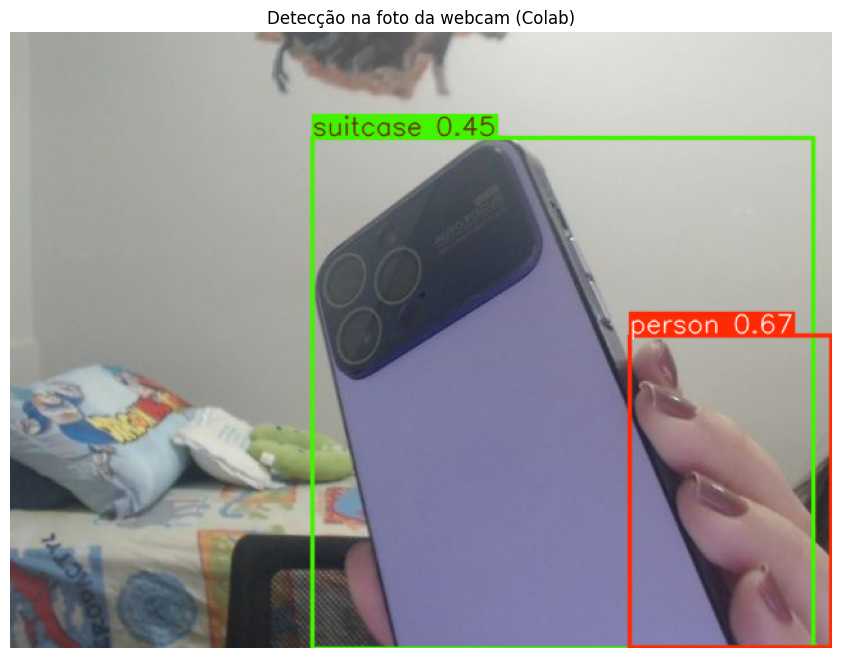

In [30]:
# ============================================================
# DETECÇÃO EM TEMPO REAL — WEBCAM (versão Google Colab)
# ============================================================
# Esta versão usa JavaScript para capturar da webcam no Colab
# Descomente e execute no Google Colab
# ============================================================

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import PIL.Image
import io

# JavaScript para capturar foto da webcam no Colab
js_code = """
async function takePhoto(quality) {
  const div = document.createElement('div');
  const capture = document.createElement('button');
  capture.textContent = 'Capturar Foto';
  div.appendChild(capture);

  const video = document.createElement('video');
  video.style.display = 'block';
  const stream = await navigator.mediaDevices.getUserMedia({video: true});

  document.body.appendChild(div);
  div.appendChild(video);
  video.srcObject = stream;
  await video.play();

  // Espera o clique no botão
  await new Promise((resolve) => capture.onclick = resolve);

  const canvas = document.createElement('canvas');
  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;
  canvas.getContext('2d').drawImage(video, 0, 0);
  stream.getVideoTracks()[0].stop();
  div.remove();
  return canvas.toDataURL('image/jpeg', quality);
}
"""

display(Javascript(js_code))
data = eval_js('takePhoto(0.8)')

# Decodifica a imagem
binary = b64decode(data.split(',')[1])
img_colab = np.array(PIL.Image.open(io.BytesIO(binary)))

# Roda YOLO
resultado_colab = modelo(img_colab)

plt.figure(figsize=(12, 8))
plt.imshow(resultado_colab[0].plot())
plt.title("Detecção na foto da webcam (Colab)")
plt.axis('off')
plt.show()

---

## 1️⃣1️⃣ Detecção em Vídeo (arquivo .mp4)

Também podemos processar um vídeo salvo, frame a frame, e salvar o resultado.

In [ ]:
# ============================================================
# DETECÇÃO EM VÍDEO — Processa e salva resultado
# ============================================================
# Descomente e altere o caminho do vídeo para usar
# O resultado é salvo em 'video_detectado.mp4'
# ============================================================

# caminho_video = "meu_video.mp4"  # <-- ALTERE AQUI
#
# captura_video = cv2.VideoCapture(caminho_video)
#
# # Configurações do vídeo de saída
# largura = int(captura_video.get(cv2.CAP_PROP_FRAME_WIDTH))
# altura = int(captura_video.get(cv2.CAP_PROP_FRAME_HEIGHT))
# fps_video = int(captura_video.get(cv2.CAP_PROP_FPS))
# total_frames = int(captura_video.get(cv2.CAP_PROP_FRAME_COUNT))
#
# # Writer para salvar o vídeo processado
# writer = cv2.VideoWriter('video_detectado.mp4',
#                           cv2.VideoWriter_fourcc(*'mp4v'),
#                           fps_video, (largura, altura))
#
# print(f"Processando vídeo: {largura}×{altura}, {fps_video} FPS, {total_frames} frames")
#
# frame_num = 0
# while True:
#     ret, frame = captura_video.read()
#     if not ret:
#         break
#
#     # Detecção
#     resultado_video = modelo(frame, verbose=False)
#     frame_anotado = resultado_video[0].plot()
#
#     # Salva o frame processado
#     writer.write(frame_anotado)
#
#     frame_num += 1
#     if frame_num % 30 == 0:
#         print(f"  Frame {frame_num}/{total_frames} ({frame_num/total_frames*100:.0f}%)")
#
# captura_video.release()
# writer.release()
# print(f"\nVídeo salvo: video_detectado.mp4")

---

## 📋 Resumo

### O que fizemos nesta aula:

| Seção | O que aprendemos |
|-------|------------------|
| Modelo | Carregamos YOLOv8 pré-treinado (80 classes COCO) com 1 linha de código |
| Detecção | Passamos imagens pelo modelo e obtivemos bounding boxes + classes + confiança |
| Análise | Extraímos cada detecção, contamos objetos por classe, recortamos objetos |
| Threshold | Ajustamos a confiança mínima para filtrar detecções fracas |
| Comparação | Nano vs Medium — trade-off entre velocidade e precisão |
| Desenho manual | Usamos OpenCV para desenhar bounding boxes, entendendo as coordenadas |
| Tempo real | Webcam com FPS e contagem de objetos em tempo real |

### Aplicações reais do YOLO:

- **Segurança**: Câmeras de vigilância detectando intrusos
- **Automotivo**: Carros autônomos detectando pedestres e veículos
- **Varejo**: Contagem de pessoas em lojas, análise de prateleiras
- **Indústria**: Detecção de defeitos em linhas de produção
- **Saúde**: Detecção de anomalias em exames de imagem
- **Agricultura**: Contagem de frutos, detecção de pragas

### Próximos passos:

- **Fine-tuning**: Treinar o YOLO com suas próprias imagens e classes
- **Segmentação**: YOLOv8-seg faz segmentação de instâncias (contorno exato do objeto)
- **Pose estimation**: YOLOv8-pose detecta pontos corporais (esqueleto)
- **Tracking**: Rastreamento de objetos ao longo de frames de vídeo